In [1]:
# packages
import matplotlib.pyplot as plt
import cooler 
import cooltools
from cooltools.lib import numutils, plotting
import numpy as np
import pandas as pd
import seaborn as sns 
import os
import bioframe
import matplotlib as mpl 

import warnings
warnings.filterwarnings("ignore")

In [2]:
basedir = os.getcwd()
print(basedir)

%cd /home/varshini/uc_analyses/
import utils
import repro
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/LoopCall_Analysis_Scripts/blood/complete_analyses/FigureGeneration
/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [3]:
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})


In [4]:
phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_expected_path = '/mnt/md0/varshini/Analysis/Blood/microc_expected'

resolution = 2000
uc_filenames = [os.path.join(uc_path, f'Sankaran_{phase}merged.250.mcool') for phase in phases]
uc_coolers = [utils.get_clr(clr_name, resolution) for clr_name in uc_filenames]

uc_exp_fnames = [f"P_s_pruned_{f.split('/')[-1].split('.')[0]}_{resolution}bp.tsv" for f in uc_filenames]
print(uc_exp_fnames)

['P_s_pruned_Sankaran_Phase1_merged_2000bp.tsv', 'P_s_pruned_Sankaran_Phase2_dedupmerged_2000bp.tsv', 'P_s_pruned_Sankaran_Phase3_dedupmerged_2000bp.tsv']


In [14]:
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v3/supp2'
if not os.path.exists(savedir):
    os.mkdir(savedir)

In [15]:
if not os.path.exists(uc_expected_path):
    os.mkdir(uc_expected_path)
    
# get expected micro-c and separation if doesn't exist
for expfile, clr in zip(uc_exp_fnames, uc_coolers):
    hg38_arms = utils.get_hg38_arms(clr, excl_ym=True)

    # select only those chromosomes available in cooler
    hg38_arms = hg38_arms[hg38_arms.chrom.isin(clr.chromnames)].reset_index(drop=True)
    #print(hg38_arms)
    if not (os.path.isfile(os.path.join(uc_expected_path, expfile))):
            cvd = cooltools.expected_cis(clr=clr, smooth=True, view_df=hg38_arms, aggregate_smoothed=True, nproc=16)
            cvd.loc[:,['dist_bp','balanced.avg.smoothed','balanced.avg.smoothed.agg']].to_csv(os.path.join(uc_expected_path, expfile), index=False, sep='\t')

P_s_pruned_Sankaran_Phase1_merged_2000bp.tsv
          dist_bp  balanced.avg.smoothed  balanced.avg.smoothed.agg
0               0                    NaN                        NaN
1            2000               0.000285                   0.000277
2            4000               0.024273                   0.023548
3            6000               0.013874                   0.013415
4            8000               0.009190                   0.008845
...           ...                    ...                        ...
1515527  95032000               0.000002                   0.000001
1515528  95034000               0.000002                   0.000001
1515529  95036000               0.000002                   0.000001
1515530  95038000               0.000002                   0.000001
1515531  95040000               0.000002                   0.000001

[1515532 rows x 3 columns]
-0.8239376380863632
88000.0
P_s_pruned_Sankaran_Phase2_dedupmerged_2000bp.tsv
          dist_bp  balanced.avg.s

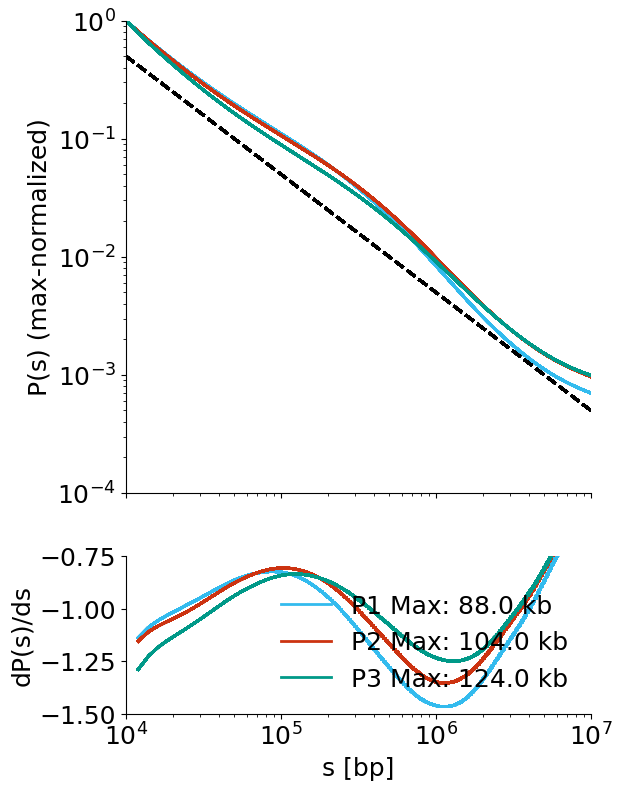

In [16]:
# plot the u-c together on one plot
#f, axs = plt.subplots(1, 2, figsize=(20, 8))

# limits for computing the derivative peak
min_dist = 10000
max_dist = 1e6

f, axs = plt.subplots(
    2, 1,
    figsize=(6, 9),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

cm = np.array(sns.color_palette("ch:start=.2,rot=-.3", n_colors=3))

cm = ["#33BBEE", "#CC3311", "#009988"]
for i in range(len(phases)):
    uc_ps = pd.read_csv(os.path.join(uc_expected_path, uc_exp_fnames[i]), sep='\t')
    
    print(uc_exp_fnames[i])
    print(uc_ps)
    
    uc_ps.loc[uc_ps['dist_bp'] < min_dist] = np.nan
    uc_s = uc_ps['dist_bp']
    uc_ps = uc_ps['balanced.avg.smoothed.agg']

    axs[0].loglog(uc_s, uc_ps/np.max(uc_ps), label=f'P{i+1}', color=cm[i], linewidth=2)
    axs[0].loglog(uc_s, (uc_s**-1)/np.max((uc_s**-1))*0.5, label=f'a=-1 scaling', color='k', linewidth=2, linestyle='--')
    
    dP_uc = np.gradient(np.log(uc_ps),
      np.log(uc_s))
    

    ind_stop = np.where((uc_s > min_dist) & (uc_s <= max_dist))[0]
    imax_local = np.argmax(dP_uc[ind_stop])
    max_der_val = dP_uc[ind_stop[imax_local]]
    max_der_s   = uc_s[ind_stop[imax_local]] 

    print(np.max(dP_uc[ind_stop]))
    print(max_der_s)
    
    axs[0].set_ylabel('P(s) (max-normalized)')
    #axs[0].set_xlabel('s (bp)')
    axs[1].semilogx(uc_s, dP_uc,label=f'P{i+1} Max: {max_der_s//1000} kb',color=cm[i],linewidth=2)
    axs[0].set_xlim([1e4, 1e7])
    axs[0].set_ylim([1e-4, 1])
    axs[1].set_xlim([1e4, 1e7])
    axs[1].set_ylim([-1.5, -0.75])
    axs[1].set_ylabel('dP(s)/ds')
    axs[1].set_xlabel('s [bp]')

plt.legend(loc='lower right', frameon=False)
#plt.show()
plt.savefig(f'{savedir}/ps_plots_reformatted.svg')

In [17]:
phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_expected_path = '/mnt/md0/varshini/Analysis/Blood/microc_expected'

resolution = 2000
uc_filenames = [os.path.join(uc_path, f'Sankaran_{phase}merged.250.mcool') for phase in phases]
uc_coolers = [utils.get_clr(clr_name, resolution) for clr_name in uc_filenames]

uc_exp_fnames_able = [f"P_s_{f.split('/')[-1].split('.')[0]}_{resolution}bp_wavg_verify2.tsv" for f in uc_filenames]
print(uc_exp_fnames)

['P_s_pruned_Sankaran_Phase1_merged_2000bp.tsv', 'P_s_pruned_Sankaran_Phase2_dedupmerged_2000bp.tsv', 'P_s_pruned_Sankaran_Phase3_dedupmerged_2000bp.tsv']


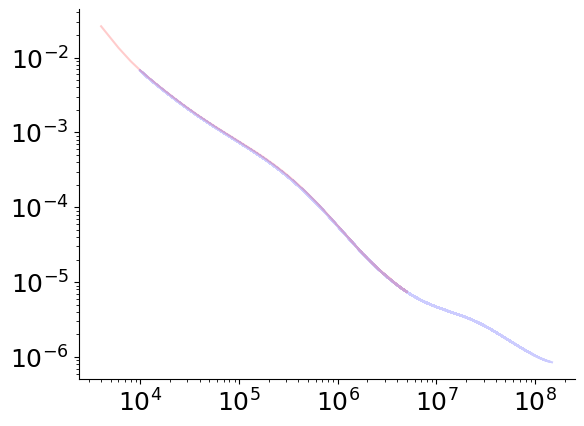

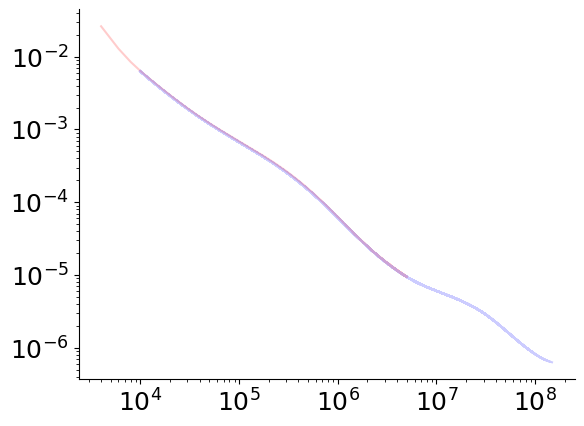

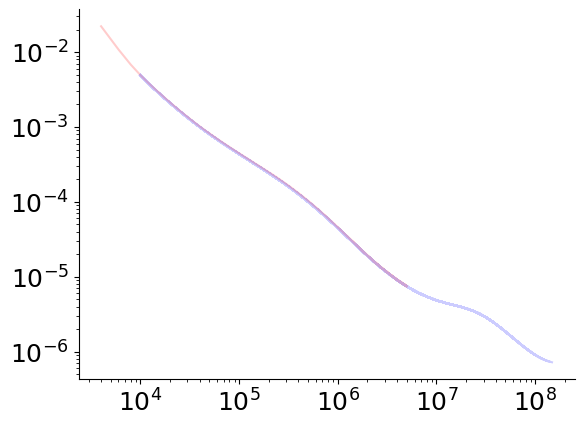

In [18]:
for i in range(len(phases)):
    plt.figure()
    
    uc_ps = pd.read_csv(os.path.join(uc_expected_path, uc_exp_fnames[i]), sep='\t')
    uc_ps.loc[uc_ps['dist_bp'] < min_dist] = np.nan
    uc_s = uc_ps['dist_bp']
    uc_ps = uc_ps['balanced.avg.smoothed.agg']
    
    uc_ps_able = pd.read_csv(os.path.join(uc_expected_path, uc_exp_fnames_able[i]), sep='\t', header=None)

    uc_s2 = uc_ps_able.index*2000
    uc_ps2 = uc_ps_able.iloc[:, 0].values
    
    plt.loglog(uc_s2, uc_ps2, color='r', alpha=0.2, label='Chrom-wavg P(s)')
    plt.loglog(uc_s, uc_ps, color='b', alpha=0.2, label='Cooltools P(s)')
    plt.xscale('log')
    plt.show()